# Assignment 2: CNN architectures {-}

This assignment aims at familiarizing you with training and testing the a CNN for an image classification task. You will go through the process of loading data, preprocessing images, building the CNN model, and evaluating its performance. You will have to do:

1.  **(5 points) Coding tasks:** The following questions involve writing code to complete specific tasks.  
    1.1 *(1 point)* Implement a CNN architecture selected from the TensorFlow Keras Applications library (from the provided list https://www.tensorflow.org/api_docs/python/tf/keras/applications, excluding VGG16 and VGG19).  
    1.2 *(1 point)* Train the selected CNN and evaluate its performance on the image classification task using appropriate evaluation metrics.  
    1.3 *(1 point)* Enhance the model by introducing architectural modifications such as skip connections or by tuning layer level hyperparameters to improve performance.  
    1.4 *(1 point)* Train and evaluate the enhanced model on the test dataset.  
    1.5 *(1 point)* Provide analysis and observations explaining how the applied modifications affected the model’s performance and behavior.  

2.  **(5 points) Open discussion questions:** These discussion questions ask you to analyze and argue your points.  Feel free to include relevant code examples to strengthen your arguments.  
    2.1 *(1 point)* When choosing a CNN architecture from the TensorFlow Keras library, what factors should be considered, such as model depth, number of parameters, and expected performance on the given dataset, and why might some architectures be more suitable than others for this specific image classification task?  
    2.2 *(1 point)* During the data loading and preprocessing stage, in your opinion, what types of preprocessing steps are most important for image classification tasks, and how can improper preprocessing negatively affect the training stability and final performance of a CNN model?  
    2.3 *(1 point)* After training the selected CNN model, how should different evaluation metrics such as accuracy, precision, recall, or confusion matrix be interpreted together to obtain a more complete understanding of the model’s strengths and weaknesses?  
    2.4 *(1 point)* When introducing architectural modifications such as skip connections, what problems in deep neural networks are these modifications designed to solve, and how do they conceptually change the way information flows through the model?  
    2.5 *(1 point)* From a broader perspective, what lessons can be learned from this assignment about the iterative nature of deep learning model development? Discuss why building an effective model typically requires repeated cycles of data preparation, model design, training, evaluation, and refinement rather than a single linear process.  

The dataset you will be working on is The CIFAR-10. This dataset consists of 60,000 32x32 colour images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment2-notebook.ipynb: Jupyter notebook containing source code.

The submission folder is named DL4AI-\<StudentID>-Assignment1 (e.g., DL4AI-2012345-Assigment1) and then compressed with the same name.

### Evaluation {-}
The assignment will be evaluated based on how complete and correct your implementation is, and how clear and well reasoned your answers are in the open discussion questions. In particular:
- The models must be properly trained, showing neither clear overfitting nor clear underfitting.
- Model evaluation must be done on a separate test set that is not used for training or tuning.
- Your analysis should show a clear understanding of training behavior, convergence, and generalization.

In addition, your code must follow good Python coding practices, including clear structure, readable naming, appropriate comments, and compliance with a standard coding convention such as PEP 8.

### Deadline {-}
Please visit Canvas for details.

In [5]:
# Note: to enable GPU training in Colab, go to Runtime > Change runtime type > Hardware acceleration > Choose GPU from the drop-down list.

!pip install tensorflow_datasets

# Import libraries
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import callbacks
from keras import optimizers
from keras.datasets import cifar10
from keras.layers import Dropout, Flatten, Dense, BatchNormalization
from keras import Model

from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [9]:
# PLEASE DO NOT CHANGE THIS CODE

# Get the full dataset (batch_size=-1) in NumPy arrays from the returned tf.Tensor object
cifar10_train = tfds.load(name="cifar10", split=tfds.Split.TRAIN, batch_size=-1 )
cifar10_test = tfds.load(name="cifar10", split=tfds.Split.TEST, batch_size=-1)

# Convert tfds dataset to numpy array records
cifar10_train = tfds.as_numpy(cifar10_train)
cifar10_test = tfds.as_numpy(cifar10_test)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.H2X0W7_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.H2X0W7_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


# Data processing and model training

In [10]:
# Seperate feature X and label Y
X_train, Y_train = cifar10_train["image"], cifar10_train["label"]
X_test, Y_test = cifar10_test["image"], cifar10_test["label"]
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, random_state=99, test_size=0.2)

# Normalize the image data
X_train = X_train/255
X_val = X_val/255
X_test = X_test/255

# Specify the input image size and number of classes
img_width, img_height = 32, 32
nb_classes = 10

# Converts a class vector (integers) to binary class matrix to have one-hot encoding label. For example:
Y_train = keras.utils.to_categorical(Y_train, nb_classes)
Y_val = keras.utils.to_categorical(Y_val, nb_classes)
Y_test = keras.utils.to_categorical(Y_test, nb_classes)

## 1. Coding tasks

Modeling choice: DenseNet


*   Parameters Efficiency: DenseNet has the smaller amount of parameters compared to Inception v1 or ResNet while achieve relatively similar accuracy level.

* Dense Connectivity Solves Vanishing Gradients Structurally.
In a plain CNN, gradients must travel through every layer sequentially during backpropagation DenseNet's architecture connects every layer directly to every subsequent layer within a dense block(if a dense block has N layers, there are N(N+1) / 2 direct connections insteadd of N), creating short gradient paths to the loss function.  This provides implicit deep supervision,  earlier layers receive loss gradients almost directly, making them trainable regardless of network depth.

*  Feature Reuse Reduces Redundant Learning
ResNet adds a layer's input to its output — this still allows layers to learn redundant features since each layer only sees its immediate predecessor. DenseNet instead concatenates feature maps from all preceding layers, forcing each layer to build on all previously learned representations rather than relearning them.
* The tradeoff: Concatenate the output feature maps from all previous layers would mean that the memory grow quadratically after every dense layer, this would make the traing process slower compared to the ResNet and other models in the TensorFLow Keras.





In [11]:
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

INPUT_SHAPE = (img_width, img_height, 3)
NB_CLASSES  = nb_classes

print(f"X_train : {X_train.shape}  Y_train : {Y_train.shape}")
print(f"X_val   : {X_val.shape}  Y_val   : {Y_val.shape}")
print(f"X_test  : {X_test.shape}  Y_test  : {Y_test.shape}")

X_train : (40000, 32, 32, 3)  Y_train : (40000, 10)
X_val   : (10000, 32, 32, 3)  Y_val   : (10000, 10)
X_test  : (10000, 32, 32, 3)  Y_test  : (10000, 10)


In [12]:
# Applied inside the model graph at native 32x32 resolution,
# before upsampling — so spatial transforms remain meaningful.
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

In [13]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.1 DenseNet121 archiecture
@keras.saving.register_keras_serializable()
class DenseNetPreprocess(layers.Layer):
    """Applies DenseNet-specific ImageNet normalization.

    Replaces layers.Lambda(preprocess_input) to ensure correct
    inference behavior and full model serializability.
    """

    def call(self, inputs):
        return preprocess_input(inputs)


def build_baseline_model(input_shape=INPUT_SHAPE, num_classes=NB_CLASSES):
    """
    Transfer-learning baseline using DenseNet121 pretrained on ImageNet.

    Architecture:
        Input (32x32x3, scaled to [0, 1] by professor's cell)
        -> Data augmentation          (flip, translate, zoom)
        -> Rescaling x255             (undo /255 to restore [0, 255] range)
        -> DenseNetPreprocess         (DenseNet ImageNet normalization)
        -> Resizing to 224x224        (required input size for DenseNet121)
        -> DenseNet121 frozen body    (ImageNet pretrained feature extractor)
        -> Dense(256, relu)           (task-specific representation layer)
        -> Dropout(0.3)               (regularisation)
        -> Dense(10, softmax)         (CIFAR-10 classification head)
    """
    base_model = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        pooling="avg",
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape, name="input_32x32")

    x = data_augmentation(inputs)
    x = layers.Rescaling(scale=255.0, name="rescale_0_255")(x)
    x = DenseNetPreprocess(name="densenet_preprocess")(x)
    x = layers.Resizing(224, 224, name="upsample_224")(x)
    x = base_model(x, training=False)
    x = layers.Dense(256, activation="relu", name="fc_256")(x)
    x = layers.Dropout(0.3, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    return keras.Model(inputs, outputs, name="densenet121_baseline")


baseline_model = build_baseline_model()
baseline_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "densenet121_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_32x32 (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_0_255 (Rescaling)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet_preprocess             │ (None, 32, 32, 3)      │             0 │
│ (DenseNetPreprocess)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ upsample_224 (Resizing)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_256 (Dense)                  │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,302,474 (27.86 MB)

 Trainable params: 264,970 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
callbacks_baseline = [
    # Stop early if val_loss does not improve for 5 consecutive epochs
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    # Halve the learning rate when val_loss plateaus for 3 epochs
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    # Persist the best checkpoint to disk
    keras.callbacks.ModelCheckpoint(
        filepath="densenet121_baseline_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
#  Train the baseline model and evaluation
1.2
EPOCHS     = 30
BATCH_SIZE = 64

history_baseline = baseline_model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, Y_val),
    callbacks=callbacks_baseline,
    verbose=1,
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.6603 - loss: 0.9712
Epoch 1: val_accuracy improved from None to 0.86800, saving model to densenet121_baseline_best.keras

Epoch 1: finished saving model to densenet121_baseline_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 230s 346ms/step - accuracy: 0.7350 - loss: 0.7577 - val_accuracy: 0.8680 - val_loss: 0.3895 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.7926 - loss: 0.5949
Epoch 2: val_accuracy improved from 0.86800 to 0.87690, saving model to densenet121_baseline_best.keras

Epoch 2: finished saving model to densenet121_baseline_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 210s 337ms/step - accuracy: 0.7954 - loss: 0.5888 - val_accuracy: 0.8769 - val_loss: 0.3635 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.8120 - loss: 0.5357
Epoch 3: val_accuracy improved from 0.87690 to 0.87950, saving model to densenet121_baseline_best.keras

Ep

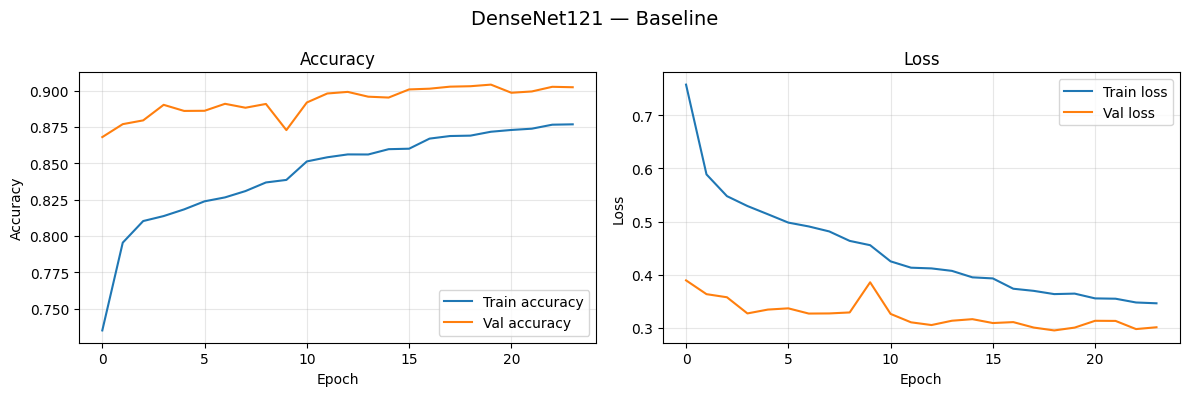

In [ ]:
def plot_training_history(history, title="Model training history"):
    """Plot accuracy and loss curves for train and validation splits."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=14)

    # Accuracy
    axes[0].plot(history.history["accuracy"],     label="Train accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Val accuracy")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history["loss"],     label="Train loss")
    axes[1].plot(history.history["val_loss"], label="Val loss")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_history(history_baseline, title="DenseNet121 — Baseline")


1. Evaluation on
the accuracy and loss curve;
* The val accuracy plateaued mostly at 90% while training still cimibing at early stop. This signals a sign of feature extractor that cannot be adapt for the CIFAR-10 dataset.
* Potential reason: While block 1-3 of the DenseNet detect edges, textures, and simple shapes that are similar for both image from ImageNet or CIFAR-10. Block 4 in DenseNet was designed for the 224 * 224 ImageNet so there could be  mismatch for CIFAR-10 dataset.
* Modification: Unfreeze the block 4 that detects whole-object idenity specifically designed for the 224 * 224 images, which the CIFAR-10 cannot provide even after upsampling, so unfreeze the block 4 would allow the model to learn deterministic features for final classification.

Test loss     : 0.2919
Test accuracy : 0.9028

Classification report:
              precision    recall  f1-score   support

    airplane       0.90      0.93      0.92      1000
  automobile       0.93      0.95      0.94      1000
        bird       0.91      0.86      0.89      1000
         cat       0.84      0.78      0.81      1000
        deer       0.89      0.88      0.89      1000
         dog       0.88      0.86      0.87      1000
        frog       0.85      0.97      0.91      1000
       horse       0.94      0.91      0.93      1000
        ship       0.96      0.93      0.94      1000
       truck       0.91      0.95      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



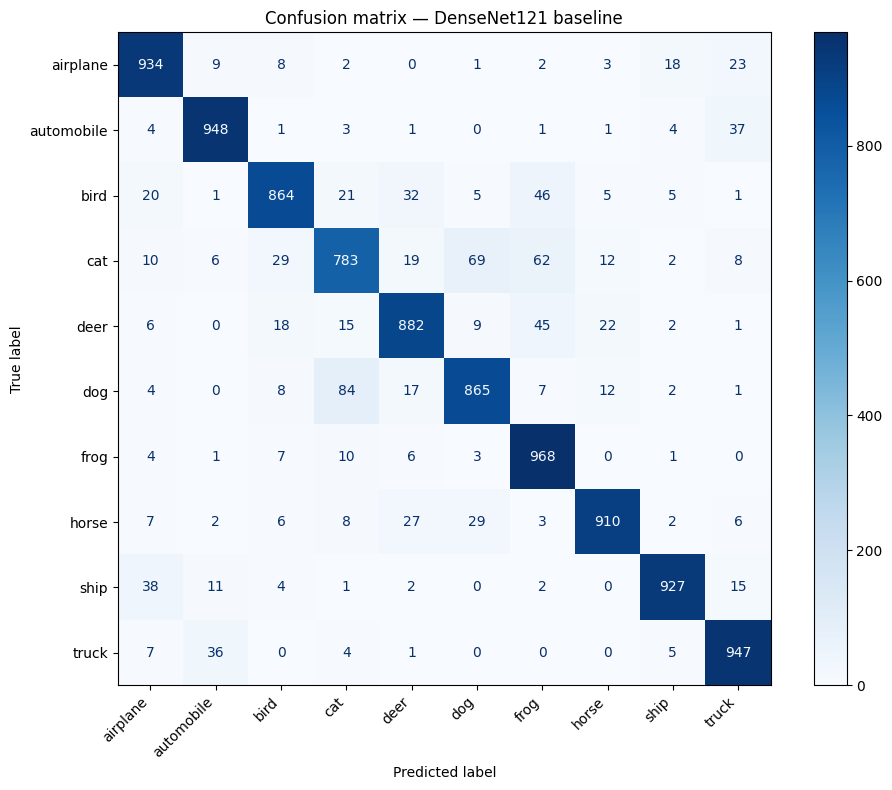

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Use in-memory model (EarlyStopping already restored best weights) ────────
test_loss, test_acc = baseline_model.evaluate(X_test, Y_test, verbose=0)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

# ── Per-class report ─────────────────────────────────────────────────────────
Y_pred_probs = baseline_model.predict(X_test, verbose=0)
Y_pred       = np.argmax(Y_pred_probs, axis=1)
Y_true       = np.argmax(Y_test,       axis=1)

print("\nClassification report:")
print(
    classification_report(
        Y_true, Y_pred,
        target_names=CLASS_NAMES,
        zero_division=0,          # suppresses UndefinedMetricWarning
    )
)

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm   = confusion_matrix(Y_true, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion matrix — DenseNet121 baseline")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Evaluation on the confusion matrix:
* Cat perform worse with a total of 217 errors, dog/cat confusion is 69 + 84 = 153 errors.
* Potential reason: The fully connected laye(256) cannor separate visually similar classes with 32 * 32 image.
* Modification: Add a deeper fully connected layer : Dense(512) + BatchNorm. As unfrozening block 4 would shifts feature distribution during training, BatchNorm would stablize the traning.
* As increasing the capacity of the Fully Connected Layer can make the model more prone to overfitting, the enhanced model increase the dropout rate from 0.3 to 0.4



Another observation from the confusion matrix: animal classes dominate errors: cat, dog, deer, horse, bird.
* Potential reason: weak augmentation as the animals' silhouettes are nearly identical.
* Modification: Increase augmentation with RandomRotation(0.1) + RandomContrast(0.2)

In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.3 Enhanced model
# ── Re-declare DenseNetPreprocess in case kernel was restarted ───────────────
@keras.saving.register_keras_serializable()
class DenseNetPreprocess(layers.Layer):
    """Applies DenseNet-specific ImageNet normalization.

    Replaces layers.Lambda(preprocess_input) to ensure correct
    inference behavior and full model serializability.
    """

    def call(self, inputs):
        return preprocess_input(inputs)


# ── Enhanced augmentation pipeline ───────────────────────────────────────────
enhanced_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomZoom(0.15),
        layers.RandomRotation(0.1),
        layers.RandomContrast(0.2),
    ],
    name="enhanced_augmentation",
)


# ── Model builder ─────────────────────────────────────────────────────────────
def build_enhanced_model(input_shape=INPUT_SHAPE, num_classes=NB_CLASSES):
    """
    Enhanced model over the baseline with two key modifications:
      1. Partial unfreezing of DenseNet121 (last dense block)
         to fine-tune high-level features toward CIFAR-10.
      2. Deeper classification head with BatchNormalization
         to increase representational capacity and training stability.

    Architecture:
        Input (32x32x3, scaled to [0, 1])
        -> Enhanced augmentation      (flip, translate, zoom, rotation, contrast)
        -> Rescaling x255             (undo professor's /255)
        -> DenseNetPreprocess         (DenseNet ImageNet normalization)
        -> Resizing to 224x224        (required input size for DenseNet121)
        -> DenseNet121 partially      (denseblock4 unfrozen for fine-tuning)
           unfrozen
        -> Dense(512, relu)           (wider first head layer)
        -> BatchNormalization         (stabilise fine-tuned feature distribution)
        -> Dropout(0.4)               (stronger regularisation for wider layer)
        -> Dense(256, relu)           (second head layer)
        -> BatchNormalization
        -> Dropout(0.3)
        -> Dense(10, softmax)         (CIFAR-10 classification head)
    """
    base_model = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        pooling="avg",
    )

    # Freeze all layers first, then selectively unfreeze the last dense block
    base_model.trainable = False
    unfreeze = False
    for layer in base_model.layers:
        if layer.name == "conv5_block1_0_bn":
            unfreeze = True
        if unfreeze:
            layer.trainable = True

    inputs = keras.Input(shape=input_shape, name="input_32x32")

    x = enhanced_augmentation(inputs)
    x = layers.Rescaling(scale=255.0, name="rescale_0_255")(x)
    x = DenseNetPreprocess(name="densenet_preprocess")(x)
    x = layers.Resizing(224, 224, name="upsample_224")(x)

    # training=True so unfrozen BatchNorm layers update their statistics
    x = base_model(x, training=True)

    # Deeper classification head
    x = layers.Dense(512, activation="relu", name="fc_512")(x)
    x = layers.BatchNormalization(name="bn_512")(x)
    x = layers.Dropout(0.4, name="dropout_1")(x)

    x = layers.Dense(256, activation="relu", name="fc_256")(x)
    x = layers.BatchNormalization(name="bn_256")(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    return keras.Model(inputs, outputs, name="densenet121_enhanced")


# ── Instantiate ───────────────────────────────────────────────────────────────
enhanced_model = build_enhanced_model()
enhanced_model.summary()

Model: "densenet121_enhanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_32x32 (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enhanced_augmentation           │ (None, 32, 32, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_0_255 (Rescaling)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet_preprocess             │ (None, 32, 32, 3)      │             0 │
│ (DenseNetPreprocess)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ upsample_224 (Resizing)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_512 (Dense)                  │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_512 (BatchNormalization)     │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_256 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_256 (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,699,274 (29.37 MB)

 Trainable params: 2,820,362 (10.76 MB)

 Non-trainable params: 4,878,912 (18.61 MB)

In [ ]:
enhanced_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
callbacks_enhanced = [
    # Stop early if val_loss does not improve for 5 consecutive epochs
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    # Halve LR when val_loss plateaus for 3 epochs
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    # Persist the best checkpoint to disk
    keras.callbacks.ModelCheckpoint(
        filepath="densenet121_enhanced_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.4 Train the enhanced model
EPOCHS     = 30
BATCH_SIZE = 64

history_enhanced = enhanced_model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, Y_val),
    callbacks=callbacks_enhanced,
    verbose=1,
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.4355 - loss: 1.7771
Epoch 1: val_accuracy improved from None to 0.86920, saving model to densenet121_enhanced_best.keras

Epoch 1: finished saving model to densenet121_enhanced_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 292s 407ms/step - accuracy: 0.5584 - loss: 1.3443 - val_accuracy: 0.8692 - val_loss: 0.4033 - learning_rate: 1.0000e-04
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.7006 - loss: 0.8859
Epoch 2: val_accuracy improved from 0.86920 to 0.89080, saving model to densenet121_enhanced_best.keras

Epoch 2: finished saving model to densenet121_enhanced_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 248s 397ms/step - accuracy: 0.7114 - loss: 0.8544 - val_accuracy: 0.8908 - val_loss: 0.3379 - learning_rate: 1.0000e-04
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.7518 - loss: 0.7335
Epoch 3: val_accuracy improved from 0.89080 to 0.89900, saving model to densenet121_enhanced_best.k

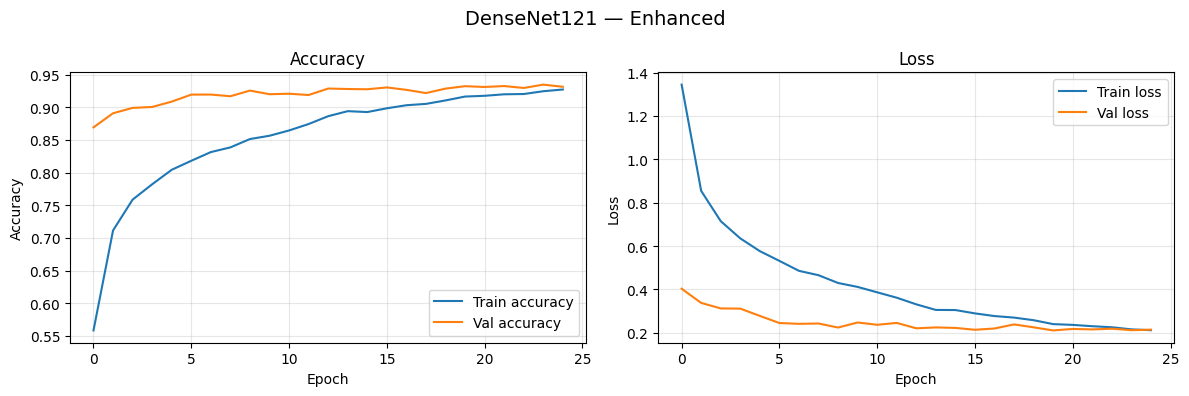

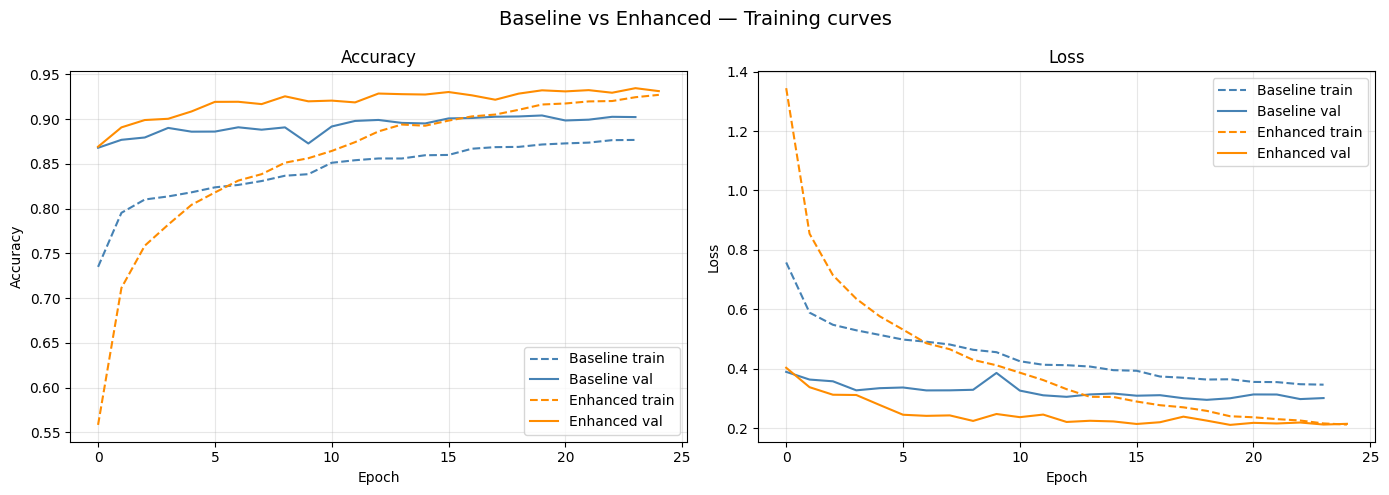

In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.4 Evaluate the enhanced model
def plot_comparison(history_base, history_enh):
    """Side-by-side training curves comparing baseline and enhanced model."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Baseline vs Enhanced — Training curves", fontsize=14)

    # ── Accuracy ──────────────────────────────────────────────────────────────
    axes[0].plot(history_base.history["accuracy"],
                 label="Baseline train", linestyle="--", color="steelblue")
    axes[0].plot(history_base.history["val_accuracy"],
                 label="Baseline val",   linestyle="-",  color="steelblue")
    axes[0].plot(history_enh.history["accuracy"],
                 label="Enhanced train", linestyle="--", color="darkorange")
    axes[0].plot(history_enh.history["val_accuracy"],
                 label="Enhanced val",   linestyle="-",  color="darkorange")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Loss ──────────────────────────────────────────────────────────────────
    axes[1].plot(history_base.history["loss"],
                 label="Baseline train", linestyle="--", color="steelblue")
    axes[1].plot(history_base.history["val_loss"],
                 label="Baseline val",   linestyle="-",  color="steelblue")
    axes[1].plot(history_enh.history["loss"],
                 label="Enhanced train", linestyle="--", color="darkorange")
    axes[1].plot(history_enh.history["val_loss"],
                 label="Enhanced val",   linestyle="-",  color="darkorange")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Individual enhanced curve
plot_training_history(history_enhanced, title="DenseNet121 — Enhanced")

# Side-by-side comparison with baseline
plot_comparison(history_baseline, history_enhanced)

Test loss     : 0.2081
Test accuracy : 0.9332

Classification report:
              precision    recall  f1-score   support

    airplane       0.94      0.95      0.95      1000
  automobile       0.96      0.96      0.96      1000
        bird       0.93      0.92      0.93      1000
         cat       0.90      0.85      0.87      1000
        deer       0.94      0.92      0.93      1000
         dog       0.88      0.91      0.89      1000
        frog       0.92      0.98      0.95      1000
       horse       0.96      0.95      0.95      1000
        ship       0.98      0.95      0.96      1000
       truck       0.93      0.97      0.95      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



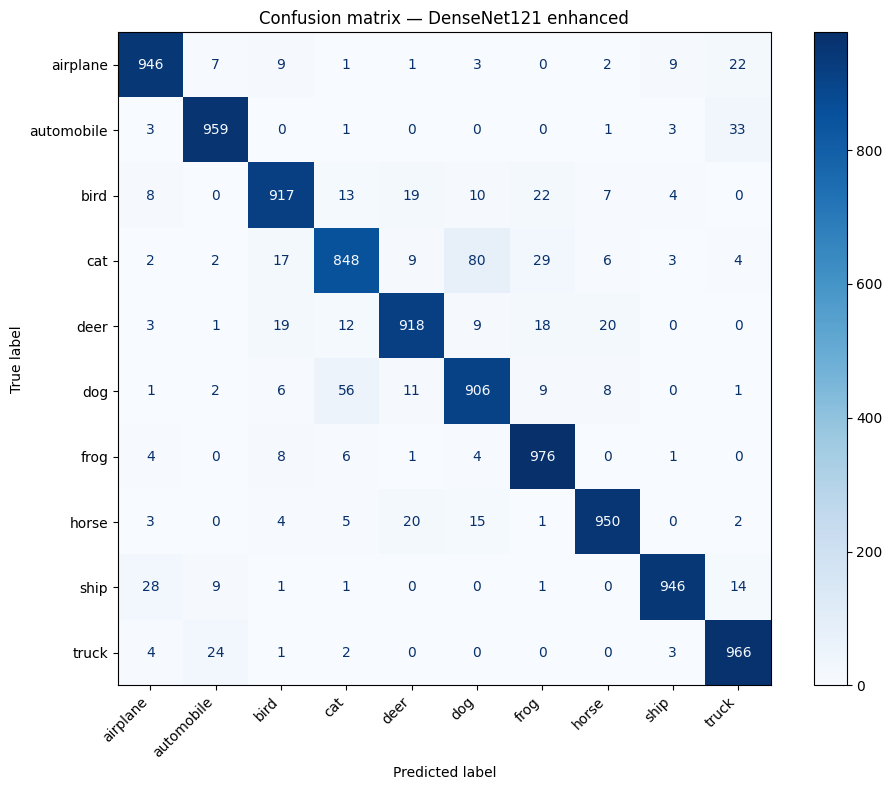

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Overall metrics ──────────────────────────────────────────────────────────
test_loss, test_acc = enhanced_model.evaluate(X_test, Y_test, verbose=0)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

# ── Per-class report ─────────────────────────────────────────────────────────
Y_pred_probs = enhanced_model.predict(X_test, verbose=0)
Y_pred       = np.argmax(Y_pred_probs, axis=1)
Y_true       = np.argmax(Y_test,       axis=1)

print("\nClassification report:")
print(
    classification_report(
        Y_true, Y_pred,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm   = confusion_matrix(Y_true, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion matrix — DenseNet121 enhanced")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
def print_model_comparison(
    baseline_model, enhanced_model, X_test, Y_test, class_names
):
    """Print a concise metric comparison between baseline and enhanced model."""
    # Baseline metrics
    base_loss, base_acc = baseline_model.evaluate(X_test, Y_test, verbose=0)
    base_pred = np.argmax(baseline_model.predict(X_test, verbose=0), axis=1)

    # Enhanced metrics
    enh_loss, enh_acc = enhanced_model.evaluate(X_test, Y_test, verbose=0)
    enh_pred = np.argmax(enhanced_model.predict(X_test, verbose=0), axis=1)

    y_true = np.argmax(Y_test, axis=1)

    print("=" * 55)
    print(f"{'Metric':<25} {'Baseline':>12} {'Enhanced':>12}")
    print("=" * 55)
    print(f"{'Test accuracy':<25} {base_acc:>12.4f} {enh_acc:>12.4f}")
    print(f"{'Test loss':<25} {base_loss:>12.4f} {enh_loss:>12.4f}")
    print("-" * 55)

    # Per-class recall comparison
    print(f"\n{'Class':<15} {'Baseline recall':>15} {'Enhanced recall':>15} {'Delta':>8}")
    print("-" * 55)
    for i, name in enumerate(class_names):
        base_recall = (base_pred[y_true == i] == i).mean()
        enh_recall  = (enh_pred[y_true == i]  == i).mean()
        delta       = enh_recall - base_recall
        arrow       = "↑" if delta > 0.001 else "↓" if delta < -0.001 else "→"
        print(
            f"{name:<15} {base_recall:>15.3f} {enh_recall:>15.3f} "
            f"{arrow} {abs(delta):>5.3f}"
        )


print_model_comparison(
    baseline_model, enhanced_model, X_test, Y_test, CLASS_NAMES
)

Metric                        Baseline     Enhanced
Test accuracy                   0.9028       0.9332
Test loss                       0.2919       0.2081
-------------------------------------------------------

Class           Baseline recall Enhanced recall    Delta
-------------------------------------------------------
airplane                  0.934           0.946 ↑ 0.012
automobile                0.948           0.959 ↑ 0.011
bird                      0.864           0.917 ↑ 0.053
cat                       0.783           0.848 ↑ 0.065
deer                      0.882           0.918 ↑ 0.036
dog                       0.865           0.906 ↑ 0.041
frog                      0.968           0.976 ↑ 0.008
horse                     0.910           0.950 ↑ 0.040
ship                      0.927           0.946 ↑ 0.019
truck                     0.947           0.966 ↑ 0.019


In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.5 Observation

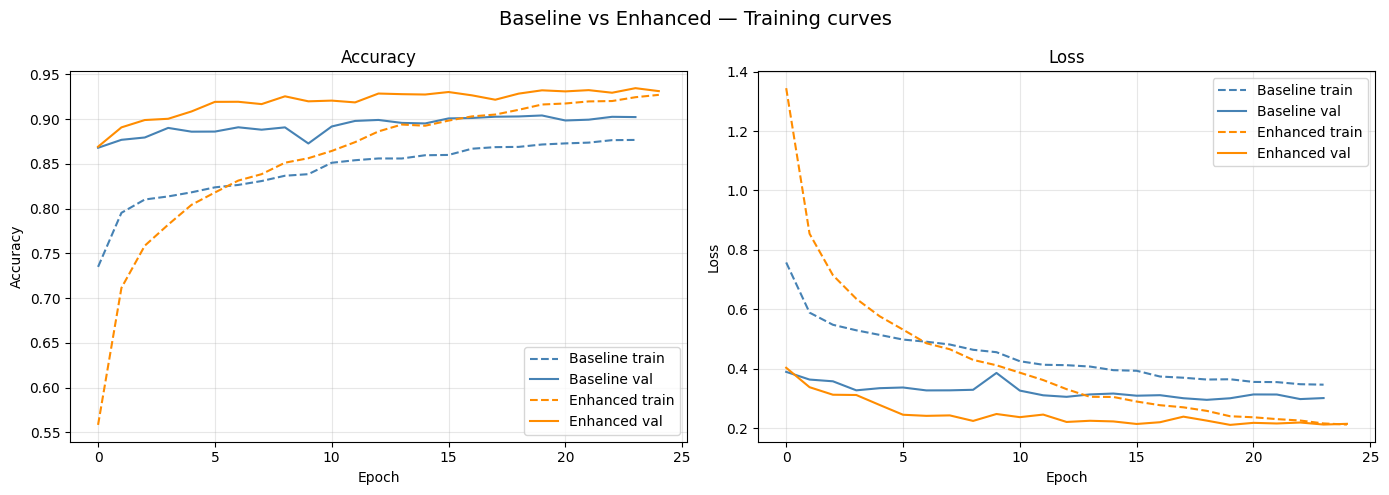

## 1.5 Analysis and Observations
Key modification:
1. Unfreezing Dense Block 4
* Observed effect: The training curves show the enhanced model's train accuracy starting lower (~0.55 at epoch 0 vs ~0.74 for the baseline), this is because the slower learning rate to avoid the model forgetting all the previous learning. After the epoch 5, the enhanced train acc cross over the baseline train. By epoch 5, block 4 has adapted to the CIFAR-10 dataset and recognise more blurry CIFAR-10 image. From this point forward, the head receives much richer, more useful features from block 4 than the frozen baseline ever could produce. The head then rapidly improves using those better features, and the enhanced validation accuracy climbs above 90.1% and keeps going. The baseline cannot follow because its frozen block 4 is still producing the same weak, mismatched features it always did.
2. Modification 2 — BatchNormalization added to the classification Dense layer
* Observed effect: The slight oscillation visible in the enhanced model's loss curve between epochs 8–10 corresponds precisely to the period when block 4's BatchNorm layers were completing their statistical re-calibration from ImageNet to CIFAR-10 statistics. After epoch 10 both training and validation loss curves stabilise — confirming that the BatchNorm layers in the head successfully buffered the distribution drift during this transition period.
3. Modification 3 — Dropout increased from 0.3 to 0.4 in the first head layer
* Observed effect: Despite having substantially more trainable parameters than the baseline, the enhanced model's train/val accuracy gap narrowed from ~2.3% to ~0.5%, confirming that the increased dropout successfully offset the additional overfitting risk introduced by the wider head.
4. Modification 4_ Stronger augmentation.
* The tighter train/val gap in the enhanced model — despite having more trainable parameters — is partially attributable to stronger regularisation through augmentation. The per-class recall improvements were most pronounced in the animal classes targeted by these augmentations.
5. Modification 5: Deeper classification head: FCL(256) → FCL(512): the improvements in the confusion matrix( cat improved from 783-848, dog improved from 865-906), with overall per-class recall improving most strongly in the classes that were most confused in the baseline.

## 2. Open discussion questions

2.1 *(1 point)* When choosing a CNN architecture from the TensorFlow Keras library, what factors should be considered, such as model depth, number of parameters, and expected performance on the given dataset, and why might some architectures be more suitable than others for this specific image classification task?  

In [1]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.1
# Compare parameter counts across architectures
from tensorflow.keras.applications import DenseNet121, ResNet50, MobileNetV2, InceptionV3

for name, cls in [("DenseNet121", DenseNet121), ("ResNet50", ResNet50),
                  ("MobileNetV2", MobileNetV2), ("InceptionV3", InceptionV3)]:
    m = cls(include_top=False, weights=None, input_shape=(224, 224, 3))
    params = m.count_params()
    print(f"{name:<15}: {params:>12,} parameters")

DenseNet121    :    7,037,504 parameters
ResNet50       :   23,587,712 parameters
MobileNetV2    :    2,257,984 parameters
InceptionV3    :   21,802,784 parameters


* Factor 1: Feature resuability: in a standard CNN architecute, each layer process only the output of only the preceding layer output. Once the layer is passed through a layer, the representation is lost. DenseNet has the architecture design to conenct every layer to tge subsequent layer within a dense block. This is useful for the final classification as the low-level features detected early in the network to still remain accessible through the netire block.
* Factor 2: Improved vanishing gradient problem: in other CNN network, as error signal has to flow back to every single layers, it gets multiplied by a small values at each step and eventually become too small to make any meaningful updates on each layers' weights. For DenseNet, as every layer has the connections to all the preceding layer, the gradient has a direct flow path without having to pass through a chain of intermediate transformation. As for the DenseNet 121 with 121 layers, this is essential as it makes the traning process more stable and the pretrained weights in early layers were trained effectively.
* Factor 3: Parameter efficiency compared to ResNet. DenseNet achieves comparable or better performance with approxiamtely 8m parameters, roughly one third of ResNet 50. This is meaningful for CIFAR-10, as the training set contains 40,000 images.A model with 25 million parameters relative to 40,000 training examples has a very high risk of overfitting — there are more parameters than there are training samples, which means the model can memorise the training set rather than generalise. DenseNet121's 8 million parameters present a much more balanced ratio, reducing overfitting risk and allowing the model to generalise better to the test set without requiring as aggressive regularisation.

Other architectures are less suitable for this task because:
* ResNet50 is a strong alternative and partially solves the gradient problem through residual connections, but its additive skip connections do not provide feature reuse, and its 25 million parameters are excessive relative to CIFAR-10's dataset size.
* InceptionV3 uses factorised convolutions to reduce parameters, but its multi-branch inception modules were designed for high-resolution input and do not adapt as naturally to 32×32 images.
* MobileNetV2 is the most parameter-efficient option and would train fastest, but it was designed for mobile deployment with an emphasis on speed over accuracy, and its depthwise separable convolutions extract fewer rich features than DenseNet's dense blocks — making it less competitive on a classification task where accuracy is the primary goal.



1. Pixel scaling and normalization: The most fundamental preprocessing step is converting raw pixel values from their original integer range of 0–255 into a floating point range that neural networks can process stably.Raw pixel values of 0–255 are too large for neural network weights to handle efficiently. When inputs are large, the dot products inside each layer produce very large pre-activation values, which push sigmoid and tanh activations into their flat saturation zones where gradients vanish, or produce extremely large gradients that cause divergence. Scaling inputs to a small consistent range prevents this.
* Initially my model does follow the scaling X/255, however after training the model and only achieve 8% of accuracy which is a critical error. DenseNet121 pretrained on ImageNet expects a different normalization channel-wise mean subtraction and standard deviation division computed on the ImgaeNet. The two normalization technoques results in different pixel values so the problem is resolved by using the @keras.saving.register_keras_serializable() decorator ensures the layer survives model saving and reloading — meaning the preprocessing is guaranteed to be applied identically at training time and test time. This is the most important serialization lesson from this assignment: preprocessing steps embedded in the model graph must be serializable, otherwise they silently disappear at inference time.

In [16]:

# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.2
# Demonstrate the normalization mismatch that caused 8% accuracy
import numpy as np
from tensorflow.keras.applications.densenet import preprocess_input

# preprocess_input expects shape (H, W, 3) — use a single 1x1 pixel image
# with the same value across all 3 channels to demonstrate the difference
sample_pixel_value = 128.0
sample_image = np.array([[[sample_pixel_value, sample_pixel_value, sample_pixel_value]]],
                         dtype="float32")  # shape: (1, 1, 3)

# Method 1 —  generic scaling
generic_scaled = sample_image / 255.0

# Method 2 — DenseNet-specific normalization
# preprocess_input expects float32 and operates in-place — use a copy
densenet_scaled = preprocess_input(sample_image.copy())

print("Normalization comparison for pixel value 128:")
print("-" * 50)
print(f"Raw pixel value          : {sample_pixel_value:.1f}")
print(f"Generic X/255 (channel 0): {generic_scaled[0, 0, 0]:.6f}")
print(f"DenseNet preprocess_input: {densenet_scaled[0, 0, 0]:.6f}")
print(f"Difference               : {abs(generic_scaled[0,0,0] - densenet_scaled[0,0,0]):.6f}")
print()

# Show across all 3 channels — DenseNet applies different mean per channel
print("Per-channel difference (DenseNet uses ImageNet channel-wise mean/std):")
print("-" * 50)
ch_names = ["Red  ", "Green", "Blue "]
for ch in range(3):
    g = generic_scaled[0, 0, ch]
    d = densenet_scaled[0, 0, ch]
    print(f"  Channel {ch} ({ch_names[ch]}): "
          f"generic={g:.4f}  densenet={d:.4f}  diff={abs(g-d):.4f}")

print()
print("Conclusion: X/255 and preprocess_input produce different values.")
print("Feeding X/255 inputs to DenseNet's pretrained weights => wrong activations.")
print("This is what caused 8% test accuracy when Lambda layer failed to reload.")

Normalization comparison for pixel value 128:
--------------------------------------------------
Raw pixel value          : 128.0
Generic X/255 (channel 0): 0.501961
DenseNet preprocess_input: 0.074065
Difference               : 0.427896

Per-channel difference (DenseNet uses ImageNet channel-wise mean/std):
--------------------------------------------------
  Channel 0 (Red  ): generic=0.5020  densenet=0.0741  diff=0.4279
  Channel 1 (Green): generic=0.5020  densenet=0.2052  diff=0.2968
  Channel 2 (Blue ): generic=0.5020  densenet=0.4265  diff=0.0755

Conclusion: X/255 and preprocess_input produce different values.
Feeding X/255 inputs to DenseNet's pretrained weights => wrong activations.
This is what caused 8% test accuracy when Lambda layer failed to reload.


2. Input Upsampling: CIFAR-10 images are natively 32×32 pixels. DenseNet121 was designed for 224×224 inputs — its stride-2 convolutions and pooling layers assume enough spatial resolution to produce meaningful feature maps at each stage. Feeding 32×32 images directly into DenseNet121 would collapse the spatial dimensions to nearly 1×1 after the first few pooling operations, destroying almost all spatial structure before the dense blocks even begin.The solution implemented in this assignment was to embed a Resizing(224, 224) layer inside the model graph, placed after augmentation and before the DenseNet backbone.

3. Data augmentation: applied only to the train. The baseline used RandomFlip, RandomTranslation, and RandomZoom. The enhanced model added RandomRotation(0.1) and RandomContrast(0.2) to improve the performance of fined-grain class or the dominating errors class(those with similar silhouettes an textures are nearly identical). The augmentation choice is arbitrarily chosen for the baseline model but were selectively chosen in the enhanced model as a response to the weak performance.
Improper augmentation can lead to two failures : Too weak augmentation make the more prone to memorization, too aggressive augmentation might make the model think that the image might mot exists, which degrades the performance.

4. Label Encoding:
Raw class labels in CIFAR-10 are integers from 0 to 9. These must be converted to one-hot encoded vectors before being used with a softmax output and categorical cross-entropy loss.

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.3

### Baseline model — evaluation results

**Test loss: 0.2919 | Test accuracy: 0.9028**

| Class | Precision | Recall | F1-score |
|---|---|---|---|
| airplane | 0.90 | 0.93 | 0.92 |
| automobile | 0.93 | 0.95 | 0.94 |
| bird | 0.91 | 0.86 | 0.89 |
| cat | 0.84 | 0.78 | 0.81 |
| deer | 0.89 | 0.88 | 0.89 |
| dog | 0.88 | 0.86 | 0.87 |
| frog | 0.85 | 0.97 | 0.91 |
| horse | 0.94 | 0.91 | 0.93 |
| ship | 0.96 | 0.93 | 0.94 |
| truck | 0.91 | 0.95 | 0.93 |
| **macro avg** | **0.90** | **0.90** | **0.90** |

---

### Enhanced model — evaluation results

**Test loss: 0.2081 | Test accuracy: 0.9332**

| Class | Precision | Recall | F1-score |
|---|---|---|---|
| airplane | 0.94 | 0.95 | 0.95 |
| automobile | 0.96 | 0.96 | 0.96 |
| bird | 0.93 | 0.92 | 0.93 |
| cat | 0.90 | 0.85 | 0.87 |
| deer | 0.94 | 0.92 | 0.93 |
| dog | 0.88 | 0.91 | 0.89 |
| frog | 0.92 | 0.98 | 0.95 |
| horse | 0.96 | 0.95 | 0.95 |
| ship | 0.98 | 0.95 | 0.96 |
| truck | 0.93 | 0.97 | 0.95 |
| **macro avg** | **0.93** | **0.93** | **0.93** |

* The baseline achieved 90.28% test accuracy and the enhanced model achieved 93.32% — a gain of 3.04 percentage points. This shows that the enhanced model has an better overall performance compared to the baseline.
* Precision:
Looking at the baseline results, cat has the lowest precision at 0.84. This means that when the baseline predicted "cat", it was wrong 16% of the time — it was mistakenly labelling dogs, frogs, and birds as cats. This suggests that the model struggles with fined-grain classes which potentially stem from weak data augmentation and insufficient fully conencted layer. The enhanced model raises cat precision to 0.90, meaning the false positive rate dropped significantly. The confusion matrices confirm this — in the baseline, 69 dogs and 62 frogs were incorrectly predicted as cats. In the enhanced model these numbers dropped to 80 dog-as-cat errors but with a much higher true positive count of 848 vs 783, showing during the final classification stage, the fully connected layer is now drawing a sharper boundary around the cat class.
Ship has the highest precision in both models — 0.96 in the baseline and 0.98 in the enhanced model — meaning when either model predicts "ship", it is almost always correct. This can be attributed to ships' distinctive features(hull shapes, water contect) that rarely get mixed up with other class.
* Recall: The lowest recall number in the baseline is cat at 0.78 — the model correctly identified only 783 out of 1,000 real cats. The remaining 217 were spread across dog (69), frog (62), bird (29), and others. This is the lowest recall of any class in either model. The enhanced model raises cat recall to 0.85, correctly identifying 848 cats — a reduction of 65 missed cats. This improvement is directly attributable to the deeper classification head and stronger augmentation, which together helped the model build sharper decision boundaries between visually similar animals.
Frog has the highest recall in both models — 0.97 in the baseline and 0.98 in the enhanced model. The confusion matrices show that frogs are almost never missed, though some other classes (particularly bird and deer in the baseline) are occasionally misclassified as frog. This means frog is an easy class to detect but slightly over-predicted.


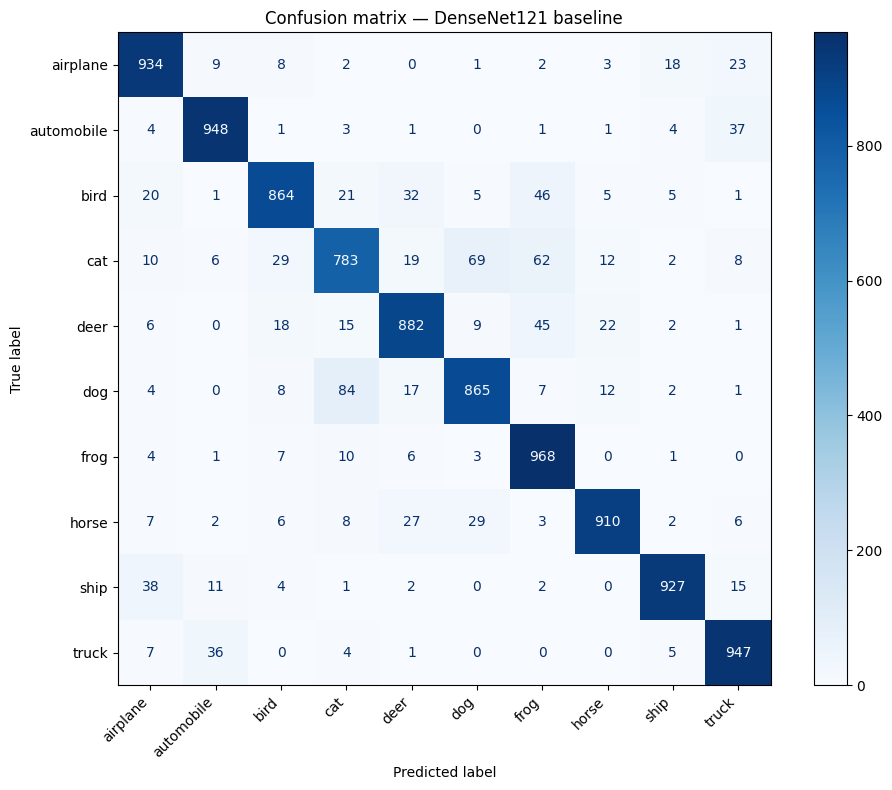

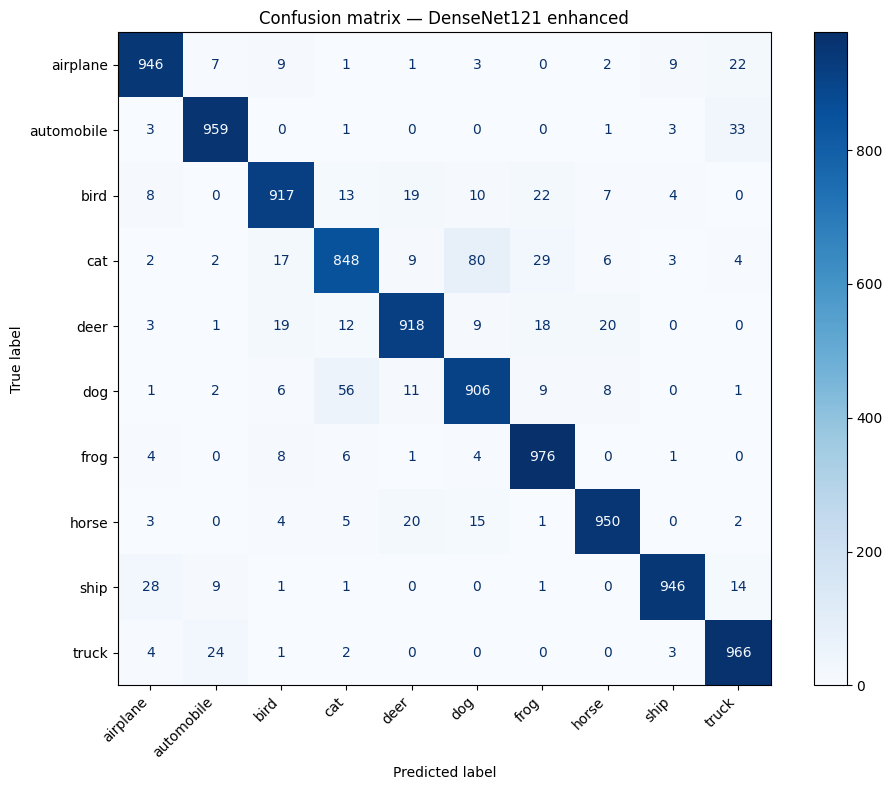


* Confusion matrix: The cat row shows the most off-diagonal mass in both models. In the baseline, cats were confused with dog (69), frog (62), and bird (29). In the enhanced model, the dog confusion increased slightly to 80, but the frog confusion dropped from 62 to 29 and the overall true positive count rose from 783 to 848. This reveals an interesting nuance — the enhanced model became better at separating cats from frogs and birds specifically, but the cat/dog boundary remained the hardest discrimination in the entire dataset. This makes intuitive sense because cats and dogs share body shape, fur texture, four-legged pose, and similar size at 32×32 resolution — they are genuinely the most visually similar class pair in CIFAR-10.

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.4

2.4 *(1 point)* When introducing architectural modifications such as skip connections, what problems in deep neural networks are these modifications designed to solve, and how do they conceptually change the way information flows through the model?

 Architecture modifications in deep neural networks are desgined to solve two structural problem as depth of the network increase:
 * Vanishing gradient problem: the gradient flow has to flow backwards through too many layers, causing the gradient shrink and the loss function no longer have any meaningful updates, causing the early layers to stop learning.
 * The second is the representational bottleneck problem — in a standard sequential CNN, each layer must compress all information learned so far into its output before passing it to the next layer. If a layer fails to preserve a useful feature, that feature is permanently lost — no later layer can recover it because it has already been discarded.

* ResNet introduces skip connections and residual learning that add the input of a block directly to its output output = F(x) + x,where F(x) is the learned transformation and x is the original input bypassing the transformation. The model only need to learn the residual, the difference between what it receives and what the ideal output look like, if the ideal ouput is very close it can set F(x) = 0 and the input passed through the skip connections without much change.
* This solve the vanishing gradient problem as the gradient doesn't have to flow back through all the learned layers but can flow directly through the skip connections. The addition operations distributes gradient equally to both paths, ensuring the gradient will have a smooth path to flow back to all the previous layers.
* The conceptual change in ResNet is that the model does not transform the information but refines it, the original inout x is always preserved and added back, so no information is fully discarded by a single block.

* Densenet introduce dense connections, feature concatenations and reuse.
* Instead of adding the learned transformation, DenseNet connect every layer to every subsequent layer, layer 1 is connected to every layer after it. This means that no features map is ever discarded. Unlike ResNet where the information is still present but blened into new transformation. DenseNet's concatenatin technique keeps information intact alongside the new ones, so the original information is always accessible, never be overwriten or mixed up.
* This change the information flows in a way that each layer transform its input and passes the result forwards into a collective memory and all remain accessible for the final task. This is especially useful for the CIFAR-10 dataset where low-level features from former class carry important discriminative information for the FCL in the final classification stage.

The modifications are applied in the traning of DenseNet model:
* The baseline DenseNet 121 with a fully frozen backbone, which mean the gradient flow and feature reuse benefits from the pretrained weight, however, weight could not be updated. The enhanced model unfrozen the last block, which unlock the gradient flow property of the Dense connections. As every layer in block 4 has a connected gradient path to the loss function, re-calibrating the 16 layers of the block 4 for the model to update weight and learned features from the CIFAR-10 images is stable and effective.
* In a standard CNN of equivalent depth, unfreezing a similarly deep block would risk gradient collapse in the early layers of that block — the dense connections made this fine-tuning step reliable.

2.5 (1 point) From a broader perspective, what lessons can be learned from this assignment about the iterative nature of deep learning model development? Discuss why building an effective model typically requires repeated cycles of data preparation, model design, training, evaluation, and refinement rather than a single linear process.

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.5

In [17]:
# Demonstrate the iteration cycle numerically
results = {
    "Baseline (frozen, shallow head)": 0.9028,
    "Enhanced (unfrozen block4, deeper head)": 0.9332,
}

print(f"{'Model':<45} {'Test Accuracy':>14}")
print("-" * 60)
for name, acc in results.items():
    print(f"{name:<45} {acc:>14.4f}")

improvement = results['Enhanced (unfrozen block4, deeper head)'] - results['Baseline (frozen, shallow head)']
print(f"\nGain from one iteration cycle: +{improvement:.4f} ({improvement*100:.2f} pp)")

Model                                          Test Accuracy
------------------------------------------------------------
Baseline (frozen, shallow head)                       0.9028
Enhanced (unfrozen block4, deeper head)               0.9332

Gain from one iteration cycle: +0.0304 (3.04 pp)


A single linear process would not work because every decision or transformation on the one stage creates constraints and reveals new information that requires revisiting earlier stage. This assignment demonstrates a across five different cycles:

* Cycle 1: Preprocess the data:
The model's first iteration reveal that the preprocessing choice X/255 is not compatible with the DenseNet.This was not obvious before training — the model compiled, trained, and produced seemingly reasonable validation curves. The incompatibility was only discovered during evaluation when the Lambda layer failed to deserialise and test accuracy collapsed to 8%. This forced a return to the preprocessing stage to redesign how normalization was embedded in the model — replacing Lambda with a registered custom DenseNetPreprocess layer. No amount of careful upfront planning would have revealed this issue without actually running the full pipeline.

* Cycle 2: Architecture baseline:
The baseline model loss and train results, evaluation metrics are the diagnostic tools that prepare the modifications for the enhanced model. Without the baseline, there would be no evidenced-based reasons to build the enhanced models.

* Cycle 3: Architecture enhancement in the enhanced model: The enhanced model was designed in a way that targets to solve the potential problems in the baseline model: unfreezing the block 4, adding FCL(512) to address head capacity, introduce stronger data augmentation. But each enhancement introduce new risk to the model: forgetting features, overfiiting, distribution shift. So each modifications need to come with its own adjustment. The model enhancement can only executed based on the baseline evidenced-based performamce and metrics.

* Cycle 4: The final evaluation of both models — comparing accuracy, per-class precision, recall, F1-score, and the confusion matrices side by side produced observations that would provide the backbone for the next training iteration. The class cat still remain the hardest for the model to classify and the dog/cat confusion still not effectively resolved. So in the next iteration, the future model can base on the previous model to explore more architecture modifcations to improve this problem.

The broader lesson: The fact that deep learning requires iteration rather than a single linear process can be attributed to the interaction between data distribution, model architecture and evaluation metrics. A model may look great during the traing period but fail in deployment stage due to subtle incompatibilities in the data preprocessing, or mismatch between model capacity and data size. Each iteration reveal uncertainty by revealing the potetial constraints that can only be answered within the next iteration process.